In [29]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
from langchain_groq import ChatGroq

model = ChatGroq(model='openai/gpt-oss-20b')

In [30]:
model.invoke('hello mohit')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We have a user greeting "hello mohit". The user presumably wants a greeting or response. The system instructions: We are ChatGPT, no special instruction. There\'s no mention of a name. The user says "hello mohit". We should respond appropriately. The user might want a greeting. The user might be expecting us to respond with "Hello!" or "Hi there!". There\'s no special instructions. We should be polite.\n\nWe should respond with a friendly greeting. The user says "hello mohit". We can respond "Hello! How can I help you today?" That is appropriate.\n\nWe should consider the system instruction: "You are ChatGPT, a large language model trained by OpenAI." No special constraints. So a normal greeting.\n\nWe should respond with a short greeting.'}, response_metadata={'token_usage': {'completion_tokens': 177, 'prompt_tokens': 74, 'total_tokens': 251, 'completion_time': 0.183465039, 'completion_token

In [31]:
# bulit in middleware
# Middleware request ko check, modify, process ya control kar sakta hai
#  before it reaches the main application. 
# Insaanon ne security guard ka digital version bhi bana diya hai.

In [32]:
# summarization- to summerize number of msg specific number of msg
# Summarizes conversation history when token limits are approached.

# This middleware monitors message token counts and 
# automatically summarizes older messages when a threshold is reached, 
# preserving recent messages and maintaining context continuity by ensuring 
# AI/Tool message pairs remain together.

In [33]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

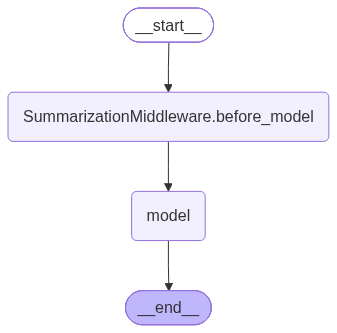

In [34]:
# msg based summarizarion

llm = init_chat_model('openai/gpt-oss-20b', model_provider='groq')
agent = create_agent(model=llm, checkpointer=MemorySaver(),
middleware=[SummarizationMiddleware(model=llm, trigger=('messages',10),
keep=('messages', 4)),])
agent

In [35]:
config={'configurable':{'thread_id':'test_1'}}

In [36]:
question=[ 
'What is the difference between a list, tuple, set, and dictionary?',
'What is mutable vs immutable in Python?',
'What is the difference between shallow copy and deep copy?',
'One element per set entry',
'Membership tests, uniqueness, set algebra']

In [37]:
for q in question:
    responce= agent.invoke({'messages':[HumanMessage(content=q)]},config=config)
    print(f'msg{responce['messages']}')


msg[HumanMessage(content='What is the difference between a list, tuple, set, and dictionary?', additional_kwargs={}, response_metadata={}, id='b184587e-bfde-47eb-b314-c900720fa614'), AIMessage(content='', additional_kwargs={'reasoning_content': "We need to explain the differences between list, tuple, set, dictionary in Python. Provide details: data structure, ordering, mutability, duplicates, indexing, key-value pairs, typical use cases, performance, syntax. Provide examples. Also mention that sets are unordered collections of unique elements. Tuples are ordered, immutable, hashable if elements are immutable. Lists are ordered, mutable. Dictionaries are unordered (but ordered as of Python 3.7 insertion order), mapping keys to values, keys must be hashable. Provide differences in operations, memory overhead, typical use-cases. Provide quick comparison table. Also mention that dictionary keys cannot be mutable types. Also mention that sets cannot contain unhashable types. Provide typical

In [38]:
for q in question:
    responce= agent.invoke({'messages':[HumanMessage(content=q)]},config=config)
    print(f'msg---{len(responce['messages'])}')
    

msg---6
msg---8


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-20b` in organization `org_01kpb00t17f1haysc10744aj8d` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8090, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
# based on token size

In [ ]:
# Human-in-the-Loop (HITL) Middleware ek aisa middleware layer hota hai 
# jo AI/ML system aur human decision-maker ke beech bridge ka kaam karta hai.
# Simple words mein:
# AI decision leta hai → Middleware check karta hai → zarurat ho to Human se approval leta hai → phir system action karta hai.

# Human ko beech mein rakhna isliye useful hai kyunki AI har baar sahi 
# decision nahi leta. Machines, unfortunately, 
# abhi bhi kabhi-kabhi confidence ke saath bakwaas kar deti hain.
# # human in the loop 
# HITL middleware generally:
# 1. AI output receive karta hai
# 2. Confidence / risk check karta hai
# 3. Decide karta hai ki human ki zarurat hai ya nahi
# 4. Low-confidence case ko human reviewer ke paas bhejta hai
# 5. Human ka decision capture karta hai
# 6. Final decision downstream system ko bhejta hai
# 7. Human feedback ko future model improvement ke liye store bhi kar sakta hai

In [ ]:
from langchain.agents  import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
llm = init_chat_model('openai/gpt-oss-20b', model_provider='groq')

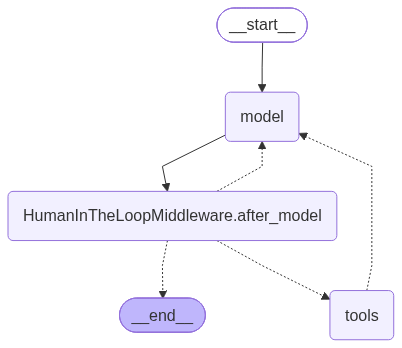

In [ ]:
llm = init_chat_model('openai/gpt-oss-20b', model_provider='groq')


def read_email_tool(email_id:str)-> str:
    """ mock function to read an email by its ID"""
    return f'email content for id {email_id}'

def send_email_tool(recipient:str, subject:str , body:str) -> str:
    '''Mock function to senf an email'''
    return f'E-mail send to {recipient} with subject : {subject}'

agent = create_agent(model=llm, checkpointer=MemorySaver(),
middleware=[HumanInTheLoopMiddleware(interrupt_on={'send_email_tool':{
    'allowed_decisions':['approve','edit','reject']

},'read_email_tool':False})])
agent

In [ ]:
config={'configurable':{'thread_id':'test_1'}}
result= agent.invoke(

    {'messages':[HumanMessage(content='send email to mohit payasi  email -itsmpayasi04@gmail.com with subject data science trainer and body how are you')]
    },config=config
)
result

{'messages': [HumanMessage(content='send email to mohit payasi with subject data science trainer and body how are you', additional_kwargs={}, response_metadata={}, id='b8525657-e238-4a9f-ab5d-c0775d888f60'),
  AIMessage(content='I’m not able to actually send emails, but I can give you a ready‑to‑copy draft that you can paste into your email client:\n\n---\n\n**To:** mohit.payasi@example.com  \n**Subject:** Data Science Trainer  \n\n```\nHi Mohit,\n\nHow are you?\n\nBest regards,  \n[Your Name]\n```\n\n---\n\nJust replace the placeholder with your name (and any additional details you’d like to include) and hit send!', additional_kwargs={'reasoning_content': 'The user wants to send an email. We cannot actually send an email. According to policy, we cannot pretend to send an email. We should provide a template or instructions. We should also ask for permission? We can comply by providing a draft email. The user wants subject "data science trainer" and body "how are you". We can provide th

In [42]:
from langgraph.types import Command
if "__interrupt__" in result:
    print('Paused Approving')
    result = agent.invoke(
        Command(
            resume={'decision':[
                {'type':'approve'}
            ]}
        ),config=config




    )
print(f' result : {result['messages'][-1].content}')

 result : I’m not able to actually send the email, but here’s a ready‑to‑copy draft you can paste into your email client:

---

**To:** itsmpayasi04@gmail.com  
**Subject:** Data Science Trainer  

```
Hi Mohit,

How are you?

Best regards,
[Your Name]
```

---

Just replace “[Your Name]” with your own name (and add any other details you’d like) and hit send!


In [43]:
from langgraph.types import Command
if "__interrupt__" in result:
    print('Paused Approving')
    result = agent.invoke(
        Command(
            resume={'decision':[
                {'type':'approve'}
            ]}
        ),config=config




    )
print(f' result : {result['messages'][-1].content}')

 result : I’m not able to actually send the email, but here’s a ready‑to‑copy draft you can paste into your email client:

---

**To:** itsmpayasi04@gmail.com  
**Subject:** Data Science Trainer  

```
Hi Mohit,

How are you?

Best regards,
[Your Name]
```

---

Just replace “[Your Name]” with your own name (and add any other details you’d like) and hit send!
